# Sudoku Solver

Description: Given values on certain cells, the algorithm will output the unique solution of the Sudoku provided the unique solution exists. 

Cell ordered <br>
0 &nbsp; 1 &nbsp; 2 &nbsp; 3 <br>
4 &nbsp; 5 &nbsp; 6 &nbsp; 7 <br>
8 &nbsp; 9 &nbsp; 10 11<br>
12 13 14 15<br> 

Cell cooedinate <br>
(0,0) (0,1) (0,2) (0,3) <br>
(1,0) (1,1) (1,2) (1,3) <br>
(2,0) (2,1) (2,2) (2,3) <br>
(3,0) (3,1) (3,2) (3,3) <br>

Qubit ordered <br>
0 &nbsp; 2 &nbsp; 4 &nbsp; 6 <br>
8 &nbsp; 10 12 14<br>
16 18 20 22<br>
24 26 28 30<br>

In [ ]:
# Ordering cells

# row group
row = []
for r in range(n**2):
    pin = r * n**2
    row.append( [pin, pin+1, pin+2, pin+3] )

# column group
column = []
for c in range(n**2):
    pin = c
    column.append( [pin, pin + n**2, pin + 2 * n**2, pin + 3 * n**2] )

# block group
block = []
for b in range(n**2):
    pin = b//n * n**2 * n + b%2 * n
    block.append( [pin, pin+1, pin+n**2, pin+n**2+1] )

#### Enter known cell values
enter 0 ~ 4 in each cell. 0 represents known value. 
e.g.:  
0034  
0012  
2341  
4123 


In [77]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np
import itertools

In [179]:
N_qubit = 8  # N_qubit = 2 * (# of unknown cells) 

In [181]:
N_check = 3 #

#### match_gate() 

In [151]:
# complement_4_gate: given a, know which qubits X gates applied on
def complement_4_gate( a ):
    template = QuantumCircuit(2, name= f"value_{a}" )
    
    if a == 4:
        template.x([0,1])
    else:
        goal = 3-a
        if goal//2 == 1:
            template.x([1])
        if goal%2 == 1:
            template.x([0])
    
    return template.to_gate()

def match_gate( target ):
    template = QuantumCircuit( len(target) * 2 + 1 , name= f"match-{target}")

    qubit = list( range(0, len(target) * 2 +1, 2))

    # Mapping indices: 
    # 0 ~ len(target) * 2 - 1 -> quantum_register
        # each value -> 2 qubits
    # len(target) * 2 -> ancilla_register

      # run through all permutation of target
    for perm in itertools.permutations( target ):
        for i in range(len(target)):  # correspond value (2i, 2i+1) to perm[i]
            template.append( complement_4_gate( perm[i] ), [2*i, 2*i+1])
            
        template.mcx(list(range(0,len(target) * 2)), len(target) * 2)

        for i in range(len(target)):  # Undo
            template.append( complement_4_gate( perm[i] ).inverse(), [2*i, 2*i+1])  
    
    return template.to_gate()


## Marker Oracle U

## Marker Circuit

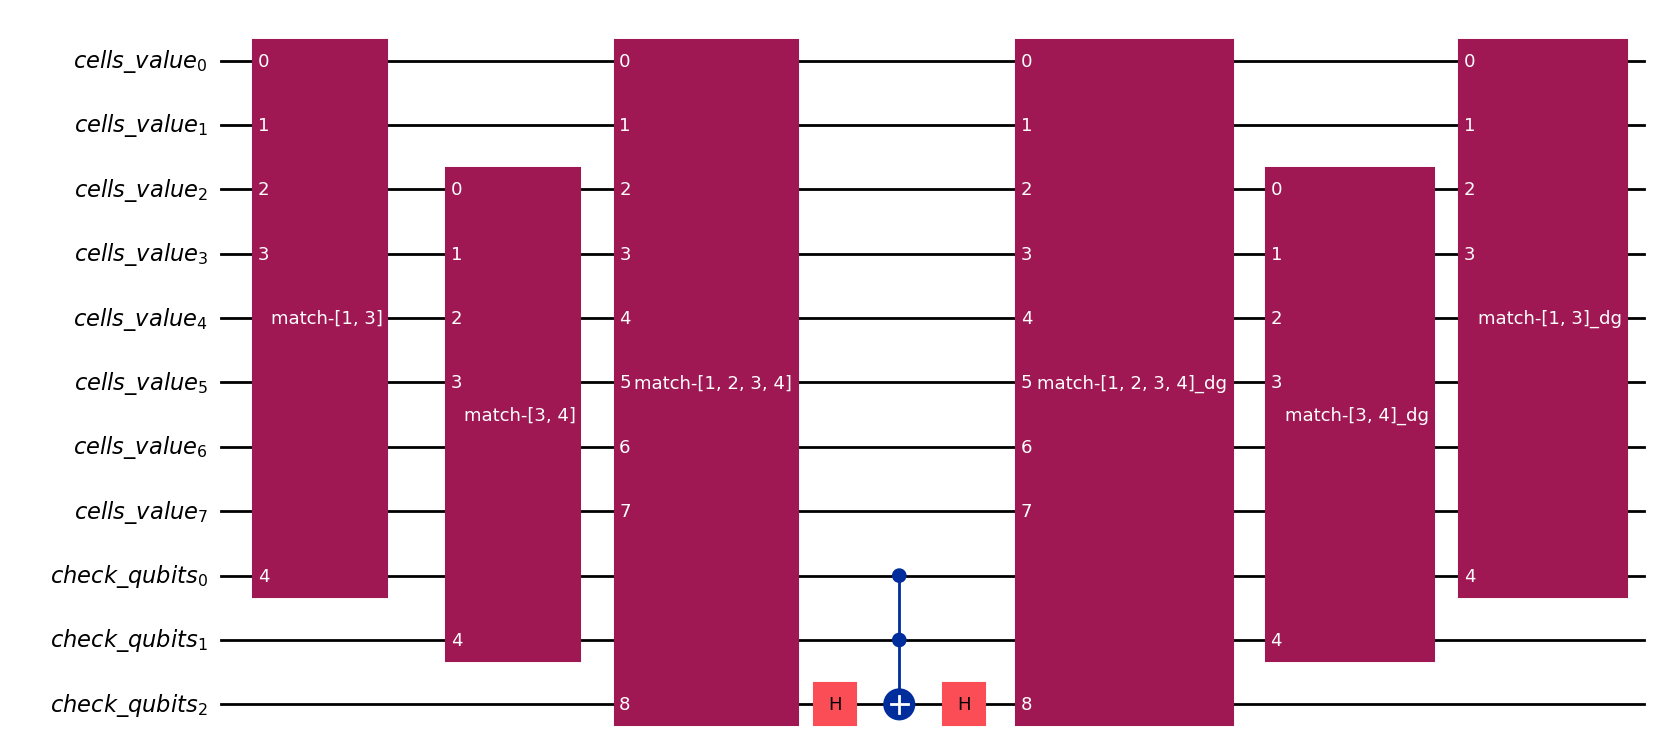

In [190]:
### Marker circuit (using checker gates)

qr = QuantumRegister(size=N_qubit, name="cells_value") #quantum_register
ar = QuantumRegister(size=N_check, name="check_qubits") #ancilla_register

marker_circuit = QuantumCircuit(qr, ar, name="marker" )

    # oracle 
marker_circuit.append( match_gate([1,3]), [qr[0], qr[1], qr[2], qr[3], ar[0]] )  # column 1
marker_circuit.append( match_gate([3,4]), [qr[2], qr[3], qr[4], qr[5], ar[1]] )  # row 2
marker_circuit.append( match_gate([1,2,3,4]), [qr[0], qr[1], qr[2], qr[3], qr[4], qr[5], qr[6], qr[7], ar[2]] )  # block 1
    
# marker_circuit.x(ar[2:])
marker_circuit.h(ar[-1])
marker_circuit.mcx( ar[0:-1], ar[-1] )
marker_circuit.h(ar[-1])
# marker_circuit.x(ar[2:])

# marker_circuit.z(ar[0])

  # Undo
marker_circuit.append( match_gate([1,2,3,4]).inverse(), [qr[0], qr[1], qr[2], qr[3], qr[4], qr[5], qr[6], qr[7], ar[2]] )
marker_circuit.append( match_gate([3,4]).inverse(), [qr[2], qr[3], qr[4], qr[5], ar[1]] )
marker_circuit.append( match_gate([1,3]).inverse(), [qr[0], qr[1], qr[2], qr[3], ar[0]] )


# draw
marker_circuit.draw(output="mpl")

#### Diffuser circuit $S$

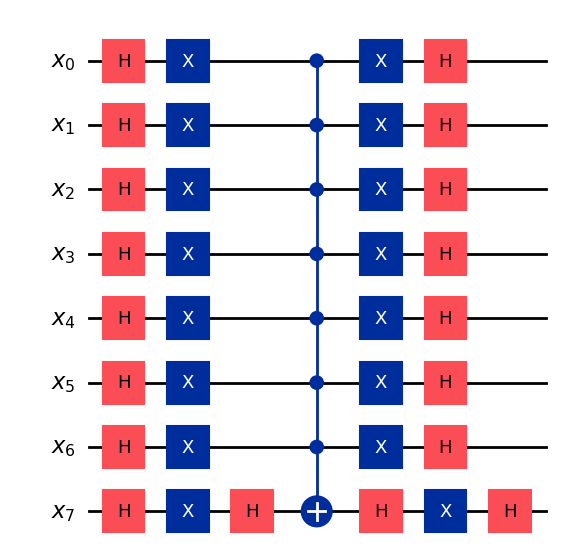

In [191]:
quantum_register = QuantumRegister(size=N_qubit, name="x")

diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

### write the rest of the code below
diffuser_circuit.h( quantum_register )

diffuser_circuit.x( quantum_register )
  # mcz gate
diffuser_circuit.h(quantum_register[-1])
diffuser_circuit.mcx( quantum_register[0:-1], quantum_register[-1] )
diffuser_circuit.h(quantum_register[-1])

diffuser_circuit.x( quantum_register )


diffuser_circuit.h( quantum_register )

###

diffuser_circuit.draw(output="mpl")

In [192]:
U = marker_circuit.to_gate()
D = diffuser_circuit.to_gate()

What is the number of iteration, $K$, that you will need?

In [193]:
N = 2**N_qubit

### K = ? (write it as a function of N)
theta = 2 * np.arcsin( N**(-1/2) )
K = int( np.rint( (np.pi / (2*theta) ) - 1/2 ) )
K

12

#### Condition preparation

In [194]:
# qr = QuantumRegister(size=N_qubit, name="x")
# condition_preparation_circuit = QuantumCircuit(qr, name="Condition preparation")


# # input known cells' value
# condition_preparation_circuit.x([qr[5], qr[10], qr[13]])

# # to gate
# Prep = condition_preparation_circuit.to_gate()

# condition_preparation_circuit.draw(output="mpl")

# Full Grover circuit

Construct the full Grover search circuit and check the probabilities as the end.

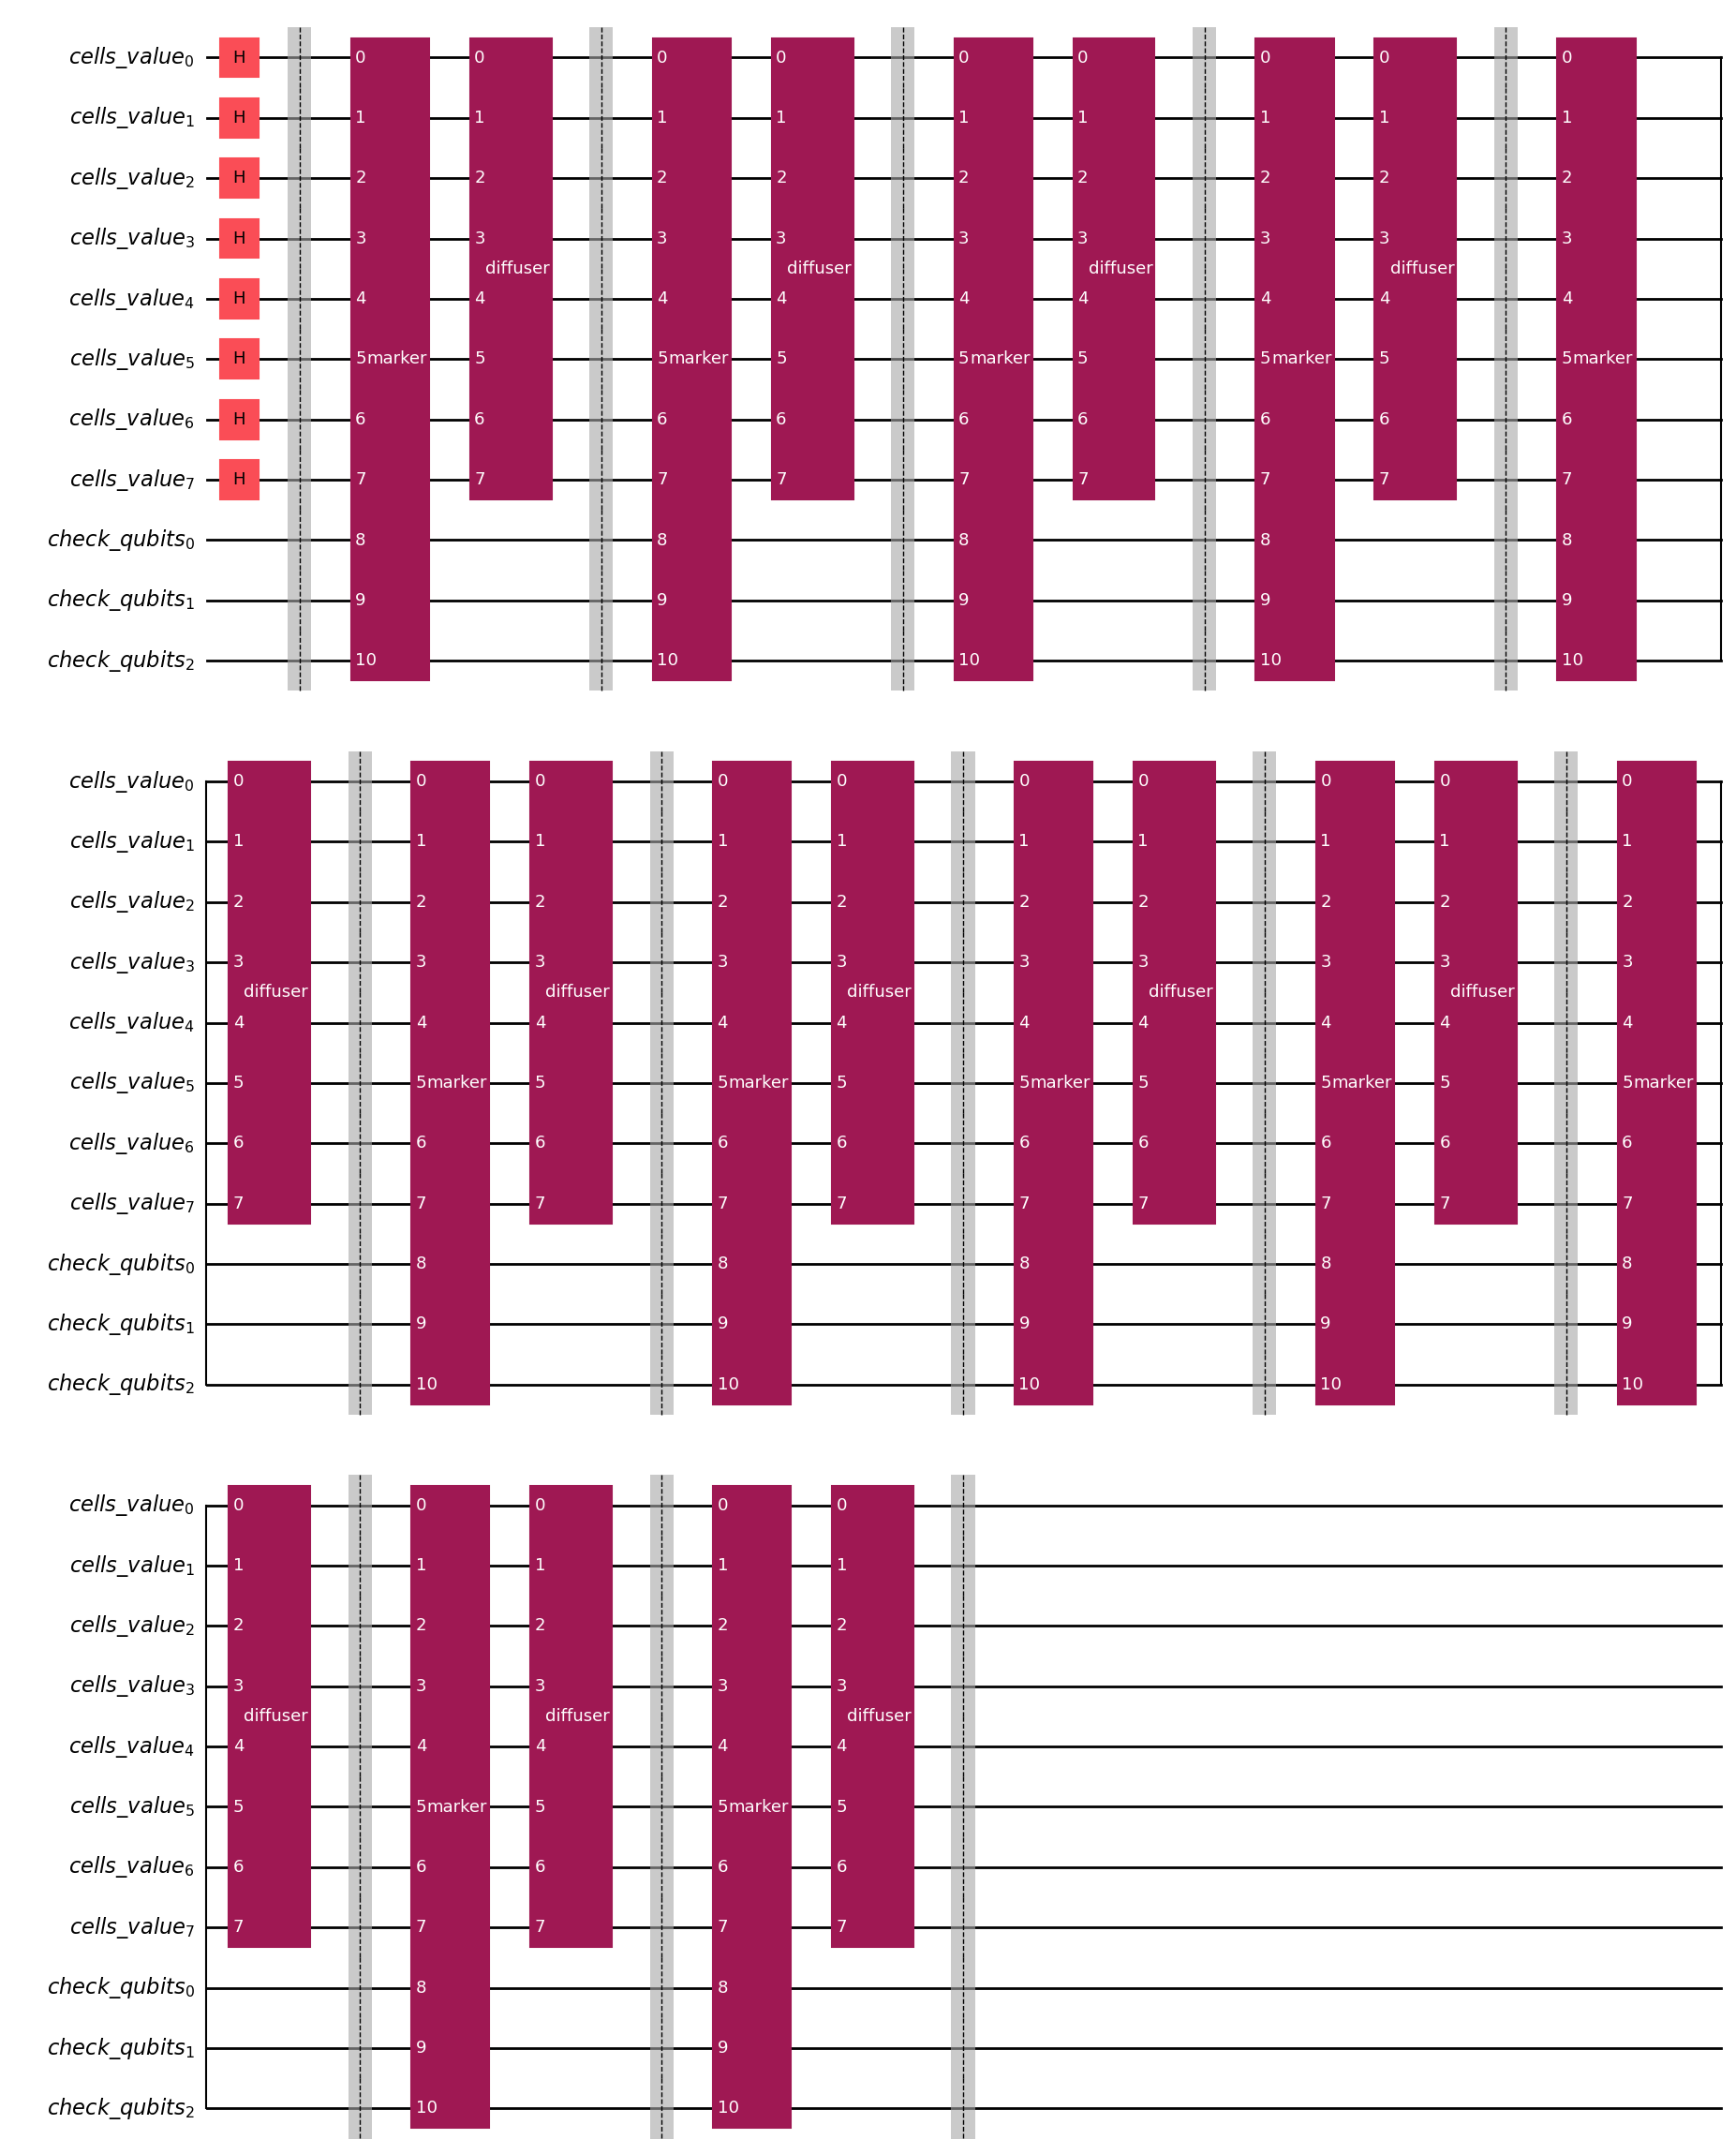

In [195]:
q_register = QuantumRegister(size=N_qubit, name="cells_value")
a_register = QuantumRegister(size=N_check, name="check_qubits")

grover_circuit = QuantumCircuit(q_register, a_register, name="Grover circuit")

### prepare |++...++> state to unknow q_register
grover_circuit.h(q_register)


### write the rest of the code below
    # iterate K times
for i in range(K):
    grover_circuit.barrier()

    grover_circuit.compose(U, inplace=True)
    grover_circuit.compose(D, inplace=True)
    

grover_circuit.barrier()

# grover_circuit.h([q_register[0], q_register[1]])

###

grover_circuit.draw(output="mpl")

In [196]:
psi = Statevector(grover_circuit)
psi.probabilities().argmax()

141

In [197]:
psi.probabilities()[141]

0.999947042079521

#### Condition Finder

Description:  
$\quad$ Given a value and its location (i,j,value), function will output 3 restriction this value imposes.  
E.g.: (0,1,3) outputs restrictions on 0th row, 1st column, 0th block (top-left block)

In [ ]:
def get_sudoku_restrictions(i, j, value):
    """
    Given a cell's row (i), column (j), and value,
    returns the restrictions imposed on the row, column, and 2x2 block.
    """
    # 1. Row restriction is just the row index i
    row_restriction = i
    
    # 2. Column restriction is just the column index j
    col_restriction = j
    
    # 3. Block restriction calculation:
    block_restriction = (i // 2) * 2 + (j // 2)
    
    return {
        "row": row_restriction,
        "column": col_restriction,
        "block": block_restriction,
        "value_imposed": value
    }

# --- Example Usage ---
# Using your example: row 0, col 1, value 3
result = get_sudoku_restrictions(0, 1, 3)

print(f"For value {result['value_imposed']} at ({0}, {1}):")
print(f"- Restricts Row: {result['row']}")
print(f"- Restricts Column: {result['column']}")
print(f"- Restricts Block: {result['block']}")

example:  
1234  
3412  
2341  
4123 

problem:  
12oo  
3o1o  
2oo1  
oo2o